<a href="https://colab.research.google.com/github/estein9825/cpre5600/blob/main/EthanCollinsPeter_6500_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TeleDAL Experiment Setup

## Install + imports

In [1]:
!pip -q install transformers datasets accelerate

In [2]:
import torch
import os, re, json, math, random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel

# Retrieve and Prepare Data

## Obtain HDFS and BGL datasets

In [8]:
# Create a workspace
!mkdir -p /content/loghub_data
%cd /content/loghub_data

# Download HDFS v1 and BGL from LogHub's Zenodo bundle
!wget -O HDFS_1.tar.gz "https://zenodo.org/records/3227177/files/HDFS_1.tar.gz?download=1"
!wget -O BGL.tar.gz    "https://zenodo.org/records/3227177/files/BGL.tar.gz?download=1"

# Extract
!tar -xzf HDFS_1.tar.gz
!tar -xzf BGL.tar.gz

# See what you got
!find /content/loghub_data -maxdepth 3 -type f | sort | sed -n '1,200p'

--2026-03-08 14:57:53--  https://zenodo.org/records/3227177/files/HDFS_1.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161886385 (154M) [application/octet-stream]
Saving to: ‘HDFS_1.tar.gz’

HDFS_1.tar.gz       100%[===================>] 154.39M  12.9MB/s    in 9.4s    

2026-03-08 14:58:03 (16.4 MB/s) - ‘HDFS_1.tar.gz’ saved [161886385/161886385]

--2026-03-08 14:58:03--  https://zenodo.org/records/3227177/files/BGL.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62936967 (60M) [application/octet-stream]
Saving to: ‘BGL.tar.gz’

BGL.tar.gz          100%[===================>]  60.02M  18.8MB/s    in 4.1s    

2026-03

#### Original Data lines

In [9]:
with open("/content/loghub_data/HDFS.log", "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 19:
            break

081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating
081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-1608999687919862906 terminating
081109 203519 145 INFO dfs.DataNode$PacketResponder: Received block blk_-1608999687919862906 of size 91178 from /10.250.10.6
081109 203519 145 INFO dfs.DataNode$PacketResponder: Receiv

### Regex masking (Table 1 style)

In [10]:
import re

BLOCK_RE = re.compile(r"(blk_-?\d+)")

HDFS_REPLACERS = [
    # Leading date/time/thread-ish prefix in HDFS logs
    (re.compile(r"^\d+\s+\d+\s+\d+\s+"), " <PREFIX> "),

    # HDFS block IDs
    (re.compile(r"\bblk_-?\d+\b"), " <BLK_ID> "),

    # IP:port first
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}:\d+\b"), " <IP_PORT> "),

    # Slash-prefixed IP:port
    (re.compile(r"/(?:\d{1,3}\.){3}\d{1,3}:\d+\b"), " /<IP_PORT> "),

    # IP only
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"), " <IP> "),

    # Slash-prefixed IP only
    (re.compile(r"/(?:\d{1,3}\.){3}\d{1,3}\b"), " /<IP> "),

    # Hadoop paths
    (re.compile(r"(?:/[\w\-.]+)+"), " <PATH> "),

    # PacketResponder IDs
    (re.compile(r"\bPacketResponder\s+\d+\b"), " PacketResponder <NUM> "),

    # Long numeric values
    (re.compile(r"\b\d{5,}\b"), " <NUM> "),

    # Remaining numbers last
    (re.compile(r"\b\d+\b"), " <NUM> "),
]

def mask_line_hdfs(s: str) -> str:
    s2 = s
    for rx, rep in HDFS_REPLACERS:
        s2 = rx.sub(rep, s2)
    return " ".join(s2.split())

In [5]:
# @title
GENERIC_REPLACERS = [
    # Specific patterns first
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}:\d+\b"), " <IP_PORT> "),
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"), " <IP> "),
    (re.compile(r"\bhttps?://\S+\b"), " <URL> "),
    (re.compile(r"(?:/[\w\-.]+)+"), " <PATH> "),
    (re.compile(r"\b\d{4}-\d{2}-\d{2}\b"), " <DATE> "),
    (re.compile(r"\b\d{2}:\d{2}:\d{2}(?:,\d+)?\b"), " <TIME> "),
    (re.compile(r"\b[a-f0-9]{8,64}\b", re.IGNORECASE), " <HEX> "),
    (re.compile(r"\b\d{5,}\b"), " <NUM> "),

    # Generic numbers LAST
    (re.compile(r"\b\d+\b"), " <NUM> "),
]

def mask_line(s: str, dataset="generic"):
    s2 = s

    # Apply dataset-specific rules first
    if dataset == "hdfs":
        for rx, rep in HDFS_REPLACERS:
            s2 = rx.sub(rep, s2)

    # Then generic normalization
    for rx, rep in GENERIC_REPLACERS:
        s2 = rx.sub(rep, s2)

    return " ".join(s2.split())

### Grouping (HDFS-style)

In [11]:
from collections import defaultdict

def parse_hdfs_groups_fast(log_path: str, progress_every=1_000_000):
    groups = defaultdict(list)

    block_search = BLOCK_RE.search
    masker = mask_line_hdfs
    groups_get = groups.__getitem__

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f, start=1):
            m = block_search(line)
            if m is None:
                continue

            bid = m.group(1)
            groups_get(bid).append(masker(line.strip()))

            if progress_every and i % progress_every == 0:
                print(f"Processed {i:,} lines...")

    return dict(groups)

def load_hdfs_labels(label_path: str):
    # Common HDFS label file format is "blk_xxx,Label"
    # Adapt as needed.
    labels = {}
    with open(label_path, "r") as f:
        for row in f:
            bid, lab = row.strip().split(",")
            labels[bid] = 1 if lab.lower() in ("anomaly", "1") else 0
    return labels

### Load Groups and Labels

In [26]:
import os
import pickle
import time

GROUPS_FILE = "/content/loghub_data/groups.pkl"
LABELS_FILE = "/content/loghub_data/labels.pkl"
LOG_FILE = "/content/loghub_data/HDFS.log"
LABEL_FILE = "/content/loghub_data/anomaly_label.csv"

start = time.perf_counter()

if os.path.exists(GROUPS_FILE) and os.path.exists(LABELS_FILE):
    print("Cached groups and labels found. Loading...")

    t0 = time.perf_counter()
    with open(GROUPS_FILE, "rb") as f:
        groups = pickle.load(f)
    print(f"groups loaded in {time.perf_counter() - t0:.2f} seconds")

    t0 = time.perf_counter()
    with open(LABELS_FILE, "rb") as f:
        labels = pickle.load(f)
    print(f"labels loaded in {time.perf_counter() - t0:.2f} seconds")

else:
    print("No cached files found. Parsing logs...")

    t0 = time.perf_counter()
    groups = parse_hdfs_groups_fast(LOG_FILE)
    print(f"groups parsed in {time.perf_counter() - t0:.2f} seconds")

    t0 = time.perf_counter()
    labels = load_hdfs_labels(LABEL_FILE)
    print(f"labels loaded in {time.perf_counter() - t0:.2f} seconds")

    print("Saving parsed data...")

    with open(GROUPS_FILE, "wb") as f:
        pickle.dump(groups, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(LABELS_FILE, "wb") as f:
        pickle.dump(labels, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("Saved cache.")

print(f"Total load/parse time: {time.perf_counter() - start:.2f} seconds")

print("Blocks:", len(groups))
print("Labels:", len(labels))

Cached groups and labels found. Loading...
groups loaded in 2.99 seconds
labels loaded in 0.19 seconds
Total load/parse time: 3.18 seconds
Blocks: 575061
Labels: 575062


## Setup Preprocessing To Decrease Noise

### Embed lines with BERT

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert.eval()

@tf.function
def bert_embed_batch(input_ids, attention_mask):
    out = bert(input_ids=input_ids, attention_mask=attention_mask, training=False)
    last_hidden = out.last_hidden_state  # [B, T, 768]
    # Sum tokens (masked) -> [B, 768]
    mask_f = tf.cast(tf.expand_dims(attention_mask, -1), tf.float32)
    summed = tf.reduce_sum(last_hidden * mask_f, axis=1)
    return summed


@torch.no_grad()
def embed_lines(lines, max_len=64, batch_size=32):
    vecs = []
    for i in range(0, len(lines), batch_size):
        batch = lines[i:i+batch_size]
        tok = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        tok = {k: v.to(device) for k, v in tok.items()}
        out = bert(**tok)
        last_hidden = out.last_hidden_state
        mask = tok["attention_mask"].unsqueeze(-1)
        summed = (last_hidden * mask).sum(dim=1)
        vecs.append(summed.cpu().numpy().astype(np.float32))
    return np.vstack(vecs)

### Identify Unique Counts

In [ ]:
all_lines = sorted({
    line
    for lines in groups.values()
    for line in lines
})

vecs_768 = embed_lines(all_lines, batch_size=len(all_lines))

line_vec_768 = {
    line: vec
    for line, vec in zip(all_lines, vecs_768)
}

### Retreive Unique Lines

In [ ]:
from collections import Counter

line_counts = Counter(
    line
    for lines in groups.values()
    for line in lines
)

for line, count in line_counts.most_common():
    print(f"{count:>10}  {line}")

### Project all unique lines to 32 dimensions

In [ ]:
import tensorflow as tf

E_BERT = 768
E = 32

projector = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(E_BERT,)),
    tf.keras.layers.Dense(E, activation=None, name="proj32")
])

all_vecs_768 = np.stack([line_vec_768[line] for line in all_lines], axis=0)
all_vecs_32 = projector(all_vecs_768, training=False).numpy().astype(np.float32)

line_vec_32 = {
    line: vec
    for line, vec in zip(all_lines, all_vecs_32)
}

### Precompile Groupings abnd Save

In [ ]:
GROUPS32_FILE = "/content/loghub_data/groups_32.pkl"

if os.path.exists(GROUPS32_FILE):
    print("Cached groups_32 found. Loading...")

    with open(GROUPS32_FILE, "rb") as f:
        groups_32 = pickle.load(f)

    print("Loaded groups_32.")

else:
    print("Building groups_32...")

    groups_32 = {
        bid: np.stack([line_vec_32[line] for line in lines], axis=0).astype(np.float32)
        for bid, lines in groups.items()
    }

    print("Saving groups_32...")

    with open(GROUPS32_FILE, "wb") as f:
        pickle.dump(groups_32, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("Saved groups_32.")

# Process Data

### Split out normal and anomalies

In [ ]:
normal_ids = [bid for bid in groups if labels.get(bid, 0) == 0]
anom_ids   = [bid for bid in groups if labels.get(bid, 0) == 1]

# 60/20/20 over NORMAL only
train_norm, temp_norm = train_test_split(normal_ids, test_size=0.40, random_state=42, shuffle=True)
val_norm, test_norm   = train_test_split(temp_norm, test_size=0.50, random_state=42, shuffle=True)

# Split anomalies 50/50 into val/test
val_anom, test_anom = train_test_split(anom_ids, test_size=0.50, random_state=42, shuffle=True)

train_ids = train_norm
val_ids   = val_norm  + val_anom
test_ids  = test_norm + test_anom

print(len(train_ids), len(val_ids), len(test_ids))

In [35]:
print(len(train_ids), len(val_ids), len(test_ids))

334933 120064 120064


## Build all train/val/test examples

In [19]:
WINDOW = 30

def make_examples_from_groups(ids, groups_32, window=30):
    X, Y = [], []

    for bid in ids:
        seq = groups_32[bid]   # [N, 32]
        for t in range(1, len(seq)):
            start = max(0, t - window)
            ctx = seq[start:t]   # [T, 32]
            tgt = seq[t]         # [32]
            X.append(ctx)
            Y.append(tgt)

    return X, Y

X_train, y_train = make_examples_from_groups(train_ids, groups_32, window=WINDOW)
X_val, y_val     = make_examples_from_groups(val_ids, groups_32, window=WINDOW)
X_test, y_test   = make_examples_from_groups(test_ids, groups_32, window=WINDOW)

print(len(X_train), len(X_val), len(X_test))

6196009 2200439 2204120


# Setup Model: Dense(32) → LSTM → Top-K head, trained with Top-K loss

## Top-K loss (TensorFlow)

In [20]:
def topk_loss(y_true, y_pred):
    """
    y_true: [B, E]
    y_pred: [B, K, E]
    Implements TeleDAL eqs (1)-(3) with cosine similarities and softmax weighting. :contentReference[oaicite:16]{index=16}
    Returns (1 - cosine) so lower is better.
    """
    y = tf.math.l2_normalize(y_true, axis=-1)   # [B,32]
    z = tf.math.l2_normalize(y_pred, axis=-1)   # [B,K,32]
    # u_k = cosine(y, z_k) -> [B, K]
    u = tf.einsum("be,bke->bk", y, z)           # [B,K]
    a = tf.nn.softmax(u, axis=-1)               # [B,K]
    # w = sum softmax(u_k) * z_k -> [B, E]
    w = tf.einsum("bk,bke->be", a, z)           # [B,32]
    w = tf.math.l2_normalize(w, axis=-1)
    cos = tf.reduce_sum(y * w, axis=-1)               # [B]
    return tf.reduce_mean(1.0 - cos)

## Build the Keras model

In [21]:
K = 8

inp = tf.keras.Input(shape=(None, E), dtype=tf.float32, name="seq")
x = tf.keras.layers.Masking(mask_value=0.0, name="mask")(inp)
x = tf.keras.layers.LSTM(64, return_sequences=True, name="lstm_1")(x)
x = tf.keras.layers.LSTM(64, return_sequences=False, name="lstm_2")(x)
x = tf.keras.layers.Dense(K * E, activation=None, name="topk_dense")(x)
out = tf.keras.layers.Reshape((K, E), name="topk")(x)

model = tf.keras.Model(inp, out, name="teledal_predict_next")
model.summary()

Model: "teledal_predict_next"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (Masking)      │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 64)  │     24,832 │ mask[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0],     │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 74,496 (291.00 KB)

 Trainable params: 74,496 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compile

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=topk_loss
)

# Setup Data Pipeline

## Create a TF Dataset

In [23]:
def make_ds_from_examples(X, Y, batch=64, shuffle=False):
    def gen():
        for x, y in zip(X, Y):
            yield np.asarray(x, dtype=np.float32), np.asarray(y, dtype=np.float32)

    spec = (
        tf.TensorSpec(shape=(None, E), dtype=tf.float32),
        tf.TensorSpec(shape=(E,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(gen, output_signature=spec)

    if shuffle:
        ds = ds.shuffle(min(len(X), 10000), seed=42, reshuffle_each_iteration=True)

    ds = ds.padded_batch(batch, padded_shapes=([None, E], [E]))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds_from_examples(X_train, y_train, batch=64, shuffle=True)
val_ds   = make_ds_from_examples(X_val, y_val, batch=64, shuffle=False)
test_ds  = make_ds_from_examples(X_test, y_test, batch=64, shuffle=False)

## Debug vector sizes

In [24]:
for xb, yb in train_ds.take(1):
    print("x:", xb.shape)
    print("y:", yb.shape)

x: (64, 23, 32)
y: (64, 32)


# Train

## Save incrementally to google drive

In [32]:
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


MODEL_PATH = "/content/drive/MyDrive/teleDAL_model.keras"

ckpt = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fit Model

In [28]:
import os
import tensorflow as tf

if os.path.exists(MODEL_PATH):
    print("Saved model found. Loading...")
    model = tf.keras.models.load_model(MODEL_PATH)
    model.summary()
    print("Model loaded.")

else:
    print("No saved model found. Training model...")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[ckpt, early]
    )

    model.save(MODEL_PATH)
    print("Model trained and saved.")

No saved model found. Training model...
Epoch 1/10
  96809/Unknown 1484s 15ms/step - loss: 4.9009e-04

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 0.00007, saving model to /content/drive/MyDrive/teleDAL_model.keras
96813/96813 ━━━━━━━━━━━━━━━━━━━━ 1966s 20ms/step - loss: 4.9007e-04 - val_loss: 6.9209e-05
Epoch 2/10
96812/96813 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.7339e-06
Epoch 2: val_loss improved from 0.00007 to 0.00005, saving model to /content/drive/MyDrive/teleDAL_model.keras
96813/96813 ━━━━━━━━━━━━━━━━━━━━ 1962s 20ms/step - loss: 6.7339e-06 - val_loss: 5.4736e-05
Epoch 3/10
96813/96813 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.3622e-06
Epoch 3: val_loss improved from 0.00005 to 0.00005, saving model to /content/drive/MyDrive/teleDAL_model.keras
96813/96813 ━━━━━━━━━━━━━━━━━━━━ 2011s 21ms/step - loss: 4.3622e-06 - val_loss: 4.6560e-05
Epoch 4/10
96811/96813 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.3640e-06
Epoch 4: val_loss improved from 0.00005 to 0.00004, saving model to /content/drive/MyDrive/teleDAL_model.keras
96813/96813 ━━━━━━━━━━━━━━━━━━━━ 2058s 21ms/step - loss: 3

In [33]:
model.summary()

Model: "teledal_predict_next"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (Masking)      │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 64)  │     24,832 │ mask[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0],     │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 223,490 (873.01 KB)

 Trainable params: 74,496 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 148,994 (582.01 KB)

# Scoring + thresholding (group anomaly score)

## Score a group

In [29]:
# @title
def score_one_step(ctx_vecs, tgt_vec):
    """
    ctx_vecs: [T, 32]
    tgt_vec : [32]
    returns: anomaly score (higher = more anomalous)
    """
    pred = model(np.expand_dims(ctx_vecs, axis=0), training=False).numpy()[0]  # [K,32]

    # normalize target and predictions
    y = tgt_vec / (np.linalg.norm(tgt_vec) + 1e-12)              # [32]
    z = pred / (np.linalg.norm(pred, axis=1, keepdims=True) + 1e-12)  # [K,32]

    # cosine similarity of each top-K prediction to target
    u = z @ y   # [K]

    # softmax over similarities, same spirit as TeleDAL Top-K loss
    a = np.exp(u - np.max(u))
    a = a / (np.sum(a) + 1e-12)

    # weighted combined prediction
    w = (a[:, None] * z).sum(axis=0)   # [32]
    w = w / (np.linalg.norm(w) + 1e-12)

    cos = np.dot(y, w)                 # higher = more normal
    anomaly_score = 1.0 - cos          # higher = more anomalous
    return float(anomaly_score)

In [30]:
# @title
def score_group(lines_32, window=30):
    """
    lines_32: list or array of shape [N, 32]
    returns:
      group_score: max anomaly score in group
      line_scores: anomaly score for each predicted step
    """
    line_scores = []

    for t in range(1, len(lines_32)):
        start = max(0, t - window)
        ctx_vecs = np.asarray(lines_32[start:t], dtype=np.float32)   # [T,32]
        tgt_vec = np.asarray(lines_32[t], dtype=np.float32)          # [32]

        s = score_one_step(ctx_vecs, tgt_vec)
        line_scores.append(s)

    if not line_scores:
        return 0.0, []

    group_score = max(line_scores)
    return group_score, line_scores

In [39]:
import numpy as np

def score_group_fast(lines_32, window=30):
    """
    lines_32: array of shape [N, 32]
    returns:
      group_score: max anomaly score in group
      line_scores: per-step anomaly scores
    """
    lines_32 = np.asarray(lines_32, dtype=np.float32)
    n = len(lines_32)

    if n < 2:
        return 0.0, []

    # Build all contexts and targets
    contexts = []
    targets = []

    for t in range(1, n):
        start = max(0, t - window)
        contexts.append(lines_32[start:t])   # [T, 32]
        targets.append(lines_32[t])          # [32]

    # Pad contexts to same length for one model call
    max_len = max(ctx.shape[0] for ctx in contexts)
    x = np.zeros((len(contexts), max_len, lines_32.shape[1]), dtype=np.float32)

    for i, ctx in enumerate(contexts):
        x[i, :ctx.shape[0], :] = ctx

    y = np.asarray(targets, dtype=np.float32)   # [B, 32]

    # One forward pass for all steps in the block
    pred = model(x, training=False).numpy()     # [B, K, 32]

    # Normalize
    y_norm = y / (np.linalg.norm(y, axis=1, keepdims=True) + 1e-12)
    z_norm = pred / (np.linalg.norm(pred, axis=2, keepdims=True) + 1e-12)

    # Cosine similarities: [B, K]
    u = np.einsum("be,bke->bk", y_norm, z_norm)

    # Softmax weighting over K
    a = np.exp(u - np.max(u, axis=1, keepdims=True))
    a = a / (np.sum(a, axis=1, keepdims=True) + 1e-12)

    # Weighted prediction: [B, 32]
    w = np.einsum("bk,bke->be", a, z_norm)
    w = w / (np.linalg.norm(w, axis=1, keepdims=True) + 1e-12)

    cos = np.sum(y_norm * w, axis=1)
    line_scores = (1.0 - cos).tolist()

    return float(np.max(line_scores)), line_scores

## Generate validation scores

In [40]:
val_scores = []
val_labels = []

for i, bid in enumerate(val_ids):
    if i % 5000 == 0:
        print(f"Validation scored: {i}/{len(val_ids)}")

    gscore, _ = score_group_fast(groups_32[bid], window=WINDOW)
    val_scores.append(gscore)
    val_labels.append(labels[bid])

print("Validation groups scored:", len(val_scores))

Validation scored: 0/120064
Validation scored: 5000/120064
Validation scored: 10000/120064
Validation scored: 15000/120064
Validation scored: 20000/120064
Validation scored: 25000/120064
Validation scored: 30000/120064
Validation scored: 35000/120064
Validation scored: 40000/120064
Validation scored: 45000/120064
Validation scored: 50000/120064
Validation scored: 55000/120064
Validation scored: 60000/120064
Validation scored: 65000/120064
Validation scored: 70000/120064
Validation scored: 75000/120064
Validation scored: 80000/120064
Validation scored: 85000/120064
Validation scored: 90000/120064
Validation scored: 95000/120064
Validation scored: 100000/120064
Validation scored: 105000/120064
Validation scored: 110000/120064
Validation scored: 115000/120064
Validation scored: 120000/120064
Validation groups scored: 120064


In [41]:
val_scores = np.asarray(val_scores)
val_labels = np.asarray(val_labels)

print("Normal mean score :", val_scores[val_labels == 0].mean())
print("Anomaly mean score:", val_scores[val_labels == 1].mean())
print("Normal median     :", np.median(val_scores[val_labels == 0]))
print("Anomaly median    :", np.median(val_scores[val_labels == 1]))

Normal mean score : 8.353762473105061e-06
Anomaly mean score: 0.007979098040610994
Normal median     : 5.364418029785156e-07
Anomaly median    : 0.00422137975692749


## F1 Scoring

In [43]:
from sklearn.metrics import f1_score

def find_best_threshold(scores, labels, num_steps=200):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    lo, hi = scores.min(), scores.max()
    best_t, best_f1 = lo, -1

    for t in np.linspace(lo, hi, num_steps):
        preds = (scores >= t).astype(int)  # higher score = more anomalous
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

best_t, best_val_f1 = find_best_threshold(val_scores, val_labels)
print("Best threshold:", best_t)
print("Best validation F1:", best_val_f1)

Best threshold: 0.0001820754166224494
Best validation F1: 0.8813690169840452


## Generate test scores


In [44]:
test_scores = []
test_labels = []

for i, bid in enumerate(test_ids):
    if i % 5000 == 0:
        print(f"Test scored: {i}/{len(test_ids)}")

    gscore, _ = score_group_fast(groups_32[bid], window=WINDOW)
    test_scores.append(gscore)
    test_labels.append(labels[bid])

print("Test groups scored:", len(test_scores))

Test scored: 0/120064
Test scored: 5000/120064
Test scored: 10000/120064
Test scored: 15000/120064
Test scored: 20000/120064
Test scored: 25000/120064
Test scored: 30000/120064
Test scored: 35000/120064
Test scored: 40000/120064
Test scored: 45000/120064
Test scored: 50000/120064
Test scored: 55000/120064
Test scored: 60000/120064
Test scored: 65000/120064
Test scored: 70000/120064
Test scored: 75000/120064
Test scored: 80000/120064
Test scored: 85000/120064
Test scored: 90000/120064
Test scored: 95000/120064
Test scored: 100000/120064
Test scored: 105000/120064
Test scored: 110000/120064
Test scored: 115000/120064
Test scored: 120000/120064
Test groups scored: 120064


In [45]:
test_scores = np.asarray(test_scores)
test_labels = np.asarray(test_labels)

normal_scores = test_scores[test_labels == 0]
anomaly_scores = test_scores[test_labels == 1]

print("Normal mean score :", normal_scores.mean())
print("Anomaly mean score:", anomaly_scores.mean())
print("Normal median     :", np.median(normal_scores))
print("Anomaly median    :", np.median(anomaly_scores))

Normal mean score : 9.814418218017207e-06
Anomaly mean score: 0.008182338431295242
Normal median     : 5.364418029785156e-07
Anomaly median    : 0.00442957878112793


## Turn test scores into predictions

In [47]:
test_preds = (np.asarray(test_scores) >= best_t).astype(int)

# Evaluate

In [48]:
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

print("Precision:", precision_score(test_labels, test_preds, zero_division=0))
print("Recall   :", recall_score(test_labels, test_preds, zero_division=0))
print("F1       :", f1_score(test_labels, test_preds, zero_division=0))
print("ROC-AUC  :", roc_auc_score(test_labels, test_scores))

print()
print(classification_report(test_labels, test_preds, zero_division=0))

Precision: 0.9632219270032163
Recall   : 0.818149423922081
F1       : 0.8847784200385357
ROC-AUC  : 0.8267038267276112

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    111645
           1       0.96      0.82      0.88      8419

    accuracy                           0.99    120064
   macro avg       0.97      0.91      0.94    120064
weighted avg       0.98      0.99      0.98    120064



## Overlapping Historgram

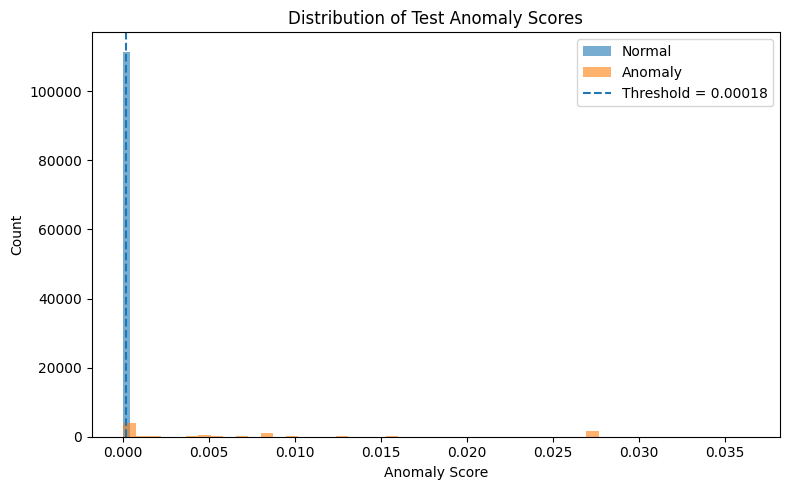

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(normal_scores, bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_scores, bins=50, alpha=0.6, label="Anomaly")
plt.axvline(best_t, linestyle="--", label=f"Threshold = {best_t:.5f}")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Distribution of Test Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

# ROC Curve

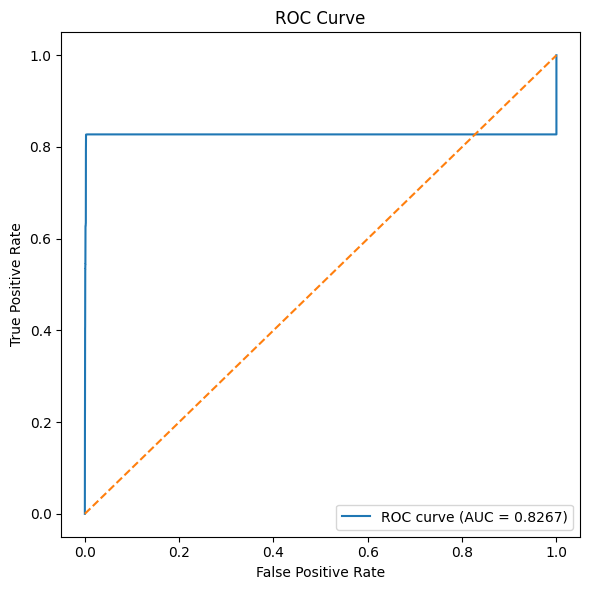

In [50]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels, test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Backup Files

In [46]:
import os
import pickle
import shutil

DRIVE_DIR = "/content/drive/MyDrive/teleDAL_backup/"
os.makedirs(DRIVE_DIR, exist_ok=True)

print("Saving backup files to:", DRIVE_DIR)

# Save embedded groups (MOST IMPORTANT)
with open(DRIVE_DIR + "groups_32.pkl", "wb") as f:
    pickle.dump(groups_32, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved groups_32.pkl")

# Save labels
with open(DRIVE_DIR + "labels.pkl", "wb") as f:
    pickle.dump(labels, f)

print("Saved labels.pkl")

# Save dataset splits
with open(DRIVE_DIR + "train_ids.pkl", "wb") as f:
    pickle.dump(train_ids, f)

with open(DRIVE_DIR + "val_ids.pkl", "wb") as f:
    pickle.dump(val_ids, f)

with open(DRIVE_DIR + "test_ids.pkl", "wb") as f:
    pickle.dump(test_ids, f)

print("Saved dataset splits")

# Save anomaly scores (if already computed)
try:
    with open(DRIVE_DIR + "val_scores.pkl", "wb") as f:
        pickle.dump(val_scores, f)
    print("Saved val_scores.pkl")
except:
    print("val_scores not available yet")

try:
    with open(DRIVE_DIR + "test_scores.pkl", "wb") as f:
        pickle.dump(test_scores, f)
    print("Saved test_scores.pkl")
except:
    print("test_scores not available yet")

# Save threshold (if already computed)
try:
    with open(DRIVE_DIR + "threshold.pkl", "wb") as f:
        pickle.dump(best_t, f)
    print("Saved threshold.pkl")
except:
    print("Threshold not available yet")

# Copy trained model
MODEL_PATH = "/content/drive/MyDrive/teleDAL_model.keras"
BACKUP_MODEL_PATH = DRIVE_DIR + "teleDAL_model.keras"

if os.path.exists(MODEL_PATH):
    shutil.copy(MODEL_PATH, BACKUP_MODEL_PATH)
    print("Copied teleDAL_model.keras to backup folder")
else:
    print("Model file not found")

print("Backup complete.")

Saving backup files to: /content/drive/MyDrive/teleDAL_backup/
Saved groups_32.pkl
Saved labels.pkl
Saved dataset splits
Saved val_scores.pkl
Saved test_scores.pkl
Saved threshold.pkl
Copied teleDAL_model.keras to backup folder
Backup complete.
